In [27]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker 
import numpy as np
import pandas as pd

In [2]:
df_tess = pd.read_csv('TESS EBS Catalogue.csv', delimiter=',', header=0)
df_tess[0:20]

,tess_id,signal_id,date_added,date_modified,source,ra,dec,pmra,pmdec,Tmag,...,sec_width_pf,sec_depth_pf,sec_pos_pf,prim_width_2g,prim_depth_2g,prim_pos_2g,sec_width_2g,sec_depth_2g,sec_pos_2g,sectors
0,185259483,1,2020-07-27 20:19:32.475646,2021-09-16 17:36:17.538222,Light Curve File (LCF),175.108299,-6.102530,5.76498,-10.347300,10.9183,...,NaN,NaN,NaN,0.320144,0.218613,0.004219,NaN,NaN,NaN,"9,36"
1,307990280,1,2020-07-27 20:19:32.859401,2021-09-16 17:36:17.578490,Light Curve File (LCF),129.235983,-67.744751,-22.88000,-12.314500,9.4314,...,0.266834,0.023058,0.514608,NaN,NaN,NaN,NaN,NaN,NaN,"9,10,11"
2,387178621,1,2020-07-27 20:19:32.958864,2021-09-16 17:36:17.621185,Light Curve File (LCF),140.414052,-55.907677,-4.22192,4.224380,11.1447,...,NaN,NaN,NaN,0.140927,0.441052,0.000095,0.176579,0.071165,0.506365,"9,10"
3,300560295,1,2020-07-27 20:19:33.639446,2021-09-16 17:36:17.671033,Light Curve File (LCF),112.915987,-68.133213,-20.41370,9.187170,10.7757,...,0.004393,0.026034,0.500378,0.006209,0.029672,0.000426,0.006037,0.029204,0.500434,"1,2,3,4,5,6,7,8,9,11,12,13,27,28,29,30,31,32,3..."
4,318185328,1,2020-07-27 20:19:33.751141,2021-09-16 17:36:17.721127,Light Curve File (LCF),162.141798,-3.624495,51.80000,-44.010000,10.4100,...,NaN,NaN,NaN,0.362418,0.300310,0.003106,0.303053,0.243379,0.503066,"9,35"
5,363326796,1,2020-07-27 20:19:33.867800,2021-09-16 17:36:17.770838,Light Curve File (LCF),146.098197,-48.837311,-43.22060,17.829600,9.8353,...,NaN,NaN,NaN,0.028907,0.087055,0.999968,0.037838,0.006008,0.500015,9
6,73764693,1,2020-07-27 20:19:34.167556,2021-09-16 17:36:17.812587,Light Curve File (LCF),155.841228,-37.616640,-33.25940,-20.125600,11.7770,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"9,36"
7,31273263,1,2020-07-27 20:20:35.595865,2021-09-16 17:36:17.853771,Light Curve File (LCF),88.103691,-68.159554,5.41806,26.235000,10.7858,...,NaN,NaN,NaN,0.019304,0.220268,0.000019,NaN,NaN,NaN,"1,2,3,4,5,6,8,9,11,12,13,28,29,31,32,33,34,35,..."
8,279955276,1,2020-07-27 20:20:35.821409,2021-09-16 17:36:17.895853,Light Curve File (LCF),82.135090,-68.603760,2.06216,13.619500,10.5877,...,NaN,NaN,NaN,0.195957,0.099307,0.999772,0.109126,0.031915,0.500008,"1,2,3,4,5,6,7,9,10,12,13"
9,144167463,1,2020-07-27 20:20:36.107545,2021-09-16 17:36:17.962779,Light Curve File (LCF),176.974420,-9.063790,-6.53859,-0.126272,9.6606,...,0.240765,0.004844,0.480508,NaN,NaN,NaN,NaN,NaN,NaN,9


In [3]:
import sys
sys.path.append('../')
from Functions.queryGrid import *

Some IP addresses of users launching heavy query showers have temporarily been disabled. Please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk) for advice. Workaround solutions for the Gaia Archive issues following the infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


In [ ]:
ids = df_tess['tess_id'].to_list()
chunk_size = 500
results = []

for i in range(0, len(ids), chunk_size):
    chunk = ids[i:i+chunk_size]
    df = queryGaia(chunk, DR=3)
    results.append(df)
    print(f"Done {i}")
    
df_gaia = pd.concat(results, ignore_index=True)

Skipping 5 stars because Gaia ID is '--'
Done 0
Skipping 4 stars because Gaia ID is '--'
Done 500
Skipping 4 stars because Gaia ID is '--'
Done 1000
Skipping 5 stars because Gaia ID is '--'
Done 1500
Skipping 2 stars because Gaia ID is '--'
Done 2000
Skipping 1 stars because Gaia ID is '--'
Done 2500
Skipping 2 stars because Gaia ID is '--'
Done 3000
Skipping 5 stars because Gaia ID is '--'
Done 3500
Skipping 5 stars because Gaia ID is '--'
Done 4000
Done 4500


,Gaia3_id,TIC_id,Gaia3_dist,Gaia3_parallax,Gaia3_G,Gaia3_T,bp_rp,bp_rp_err
0,3459295238636660352,165458777,145.475419,6.874014,10.726010,NaN,0.927716,0.032709
1,3460989036299055104,165456443,215.785717,4.634227,9.417890,7138.135254,0.421197,0.000977
2,3464532418676024064,157175641,124.547258,8.029081,9.273170,NaN,0.762967,0.041653
3,3467432208797826432,142262969,473.895681,2.110169,10.602425,6464.500000,0.640859,0.000398
4,3471021663289103872,390554357,384.290372,2.602199,8.219930,9892.428711,0.108978,0.001516
...,...,...,...,...,...,...,...,...
4542,4607233138071959936,10393493,577.244508,1.732368,12.497898,6423.139648,0.719270,0.031549
4543,4608674288577507456,18269802,328.435406,3.044739,11.175815,5580.016113,0.856182,0.015939
4544,4609102617076419456,116161302,1404.504409,0.711995,11.672544,NaN,0.588678,0.004757
4545,4609332376349201408,116163356,1335.743043,0.748647,12.212008,6428.233398,0.653093,0.020396


Median 0.7193603515625


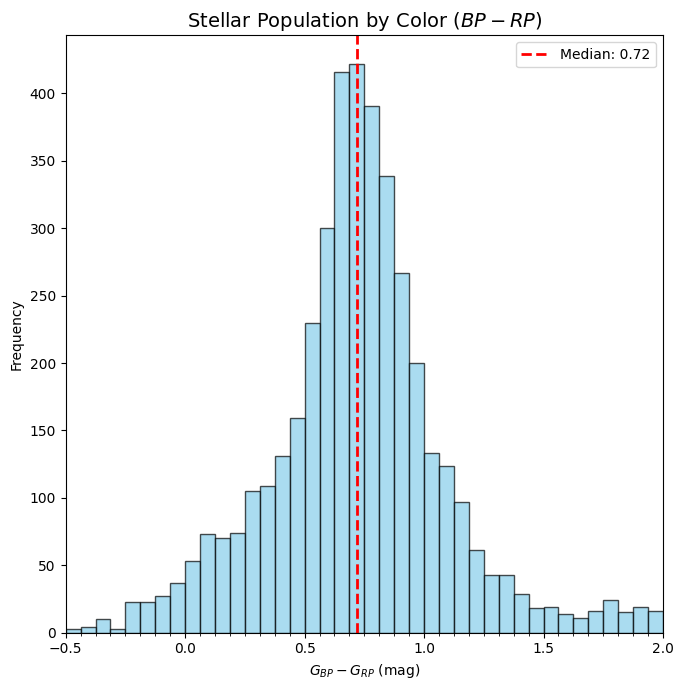

In [30]:
# 1. Square Figure Size
plt.figure(figsize=(7, 7))

filtered_colors = df_gaia['bp_rp'][(df_gaia['bp_rp'] >= -0.5) & (df_gaia['bp_rp'] <= 2.0)].dropna()
median_color = filtered_colors.median()

bins = np.linspace(-0.5, 2.0, 41)

# 2. Histogram
plt.hist(filtered_colors, bins=bins, 
         color='skyblue', edgecolor='black', alpha=0.7)

# 3. Median Line
plt.axvline(median_color, color='red', linestyle='--', linewidth=2, 
            label=f'Median: {median_color:.2f}')

ax = plt.gca()
ax.xaxis.set_minor_locator(ticker.FixedLocator(bins))

# 4. Final Square Formatting
plt.xlim(-0.5, 2.0)
plt.gca().set_box_aspect(1) # Ensures the plot box is perfectly square

plt.title('Stellar Population by Color ($BP - RP$)', fontsize=14)
plt.xlabel('$G_{BP} - G_{RP}$ (mag)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout() # Ensures labels don't get cut off in square format

print(f"Median {median_color}")
plt.show()

Median: 255.39561546222666


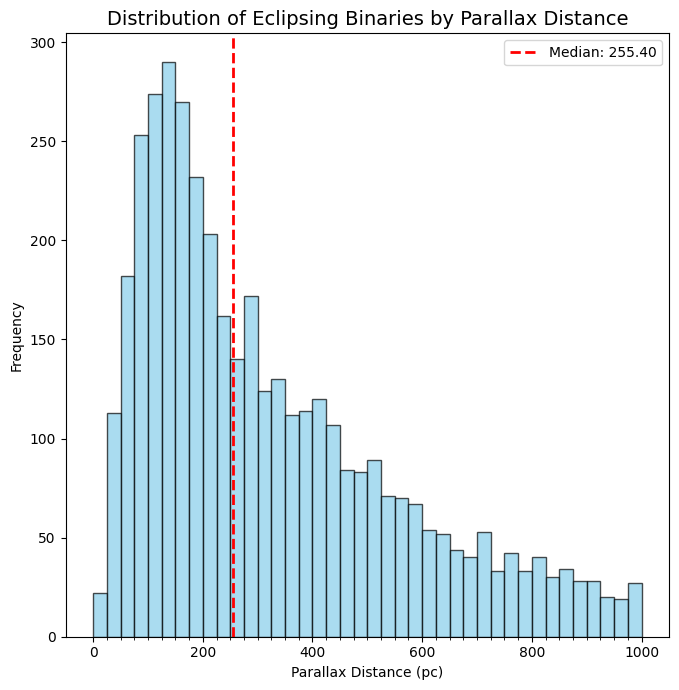

In [31]:
# 1. Square Figure Size
plt.figure(figsize=(7, 7))

parallax = df_gaia['Gaia3_dist'][(df_gaia['Gaia3_dist'] >= 0) & (df_gaia['Gaia3_dist'] <= 1000)].dropna()
median_parallax = parallax.median()

bins = np.linspace(0, 1000, 41)

# 2. Histogram
plt.hist(parallax, bins=bins, 
         color='skyblue', edgecolor='black', alpha=0.7)


# 3. Median Line
plt.axvline(median_parallax, color='red', linestyle='--', linewidth=2, 
            label=f'Median: {median_parallax:.2f}')

ax = plt.gca()
ax.xaxis.set_minor_locator(ticker.FixedLocator(bins))

# 4. Final Square Formatting
plt.gca().set_box_aspect(1) # Ensures the plot box is perfectly square

plt.title('Distribution of Eclipsing Binaries by Parallax Distance', fontsize=14)
plt.xlabel('Parallax Distance (pc)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout() # Ensures labels don't get cut off in square format

print(f"Median: {median_parallax}")
plt.show()